# Final Project: IMBD MOVIES
#### Authors: D. Whitney, C. Mott, B. Graeve
#### Course: CSC 5610
#### Date: 5/5/2026

### Part 1: Load and Clean Data

##### 1.1 Load Data

In [ ]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, mean_absolute_percentage_error


movies_df = pd.read_csv('TMDB_movie_dataset_v11.csv')

display(movies_df.head())
movies_df.info()
movies_df.describe()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,Avatar,"In the 22nd century, a paraplegic Marine is di...",79.932,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Enter the world of Pandora.,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,The Avengers,When an unexpected enemy emerges and threatens...,98.082,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Some assembly required.,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com..."


<class 'pandas.DataFrame'>
RangeIndex: 1418445 entries, 0 to 1418444
Data columns (total 24 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1418445 non-null  int64  
 1   title                 1418427 non-null  str    
 2   vote_average          1418445 non-null  float64
 3   vote_count            1418445 non-null  int64  
 4   status                1418445 non-null  str    
 5   release_date          1103168 non-null  str    
 6   revenue               1418445 non-null  int64  
 7   runtime               1418445 non-null  int64  
 8   adult                 1418445 non-null  bool   
 9   backdrop_path         352346 non-null   str    
 10  budget                1418445 non-null  int64  
 11  homepage              145804 non-null   str    
 12  imdb_id               667862 non-null   str    
 13  original_language     1418445 non-null  str    
 14  original_title        1418427 non-null  str  

,id,vote_average,vote_count,revenue,runtime,budget,popularity
count,1.418445e+06,1.418445e+06,1.418445e+06,1.418445e+06,1.418445e+06,1.418445e+06,1.418445e+06
mean,8.988704e+05,1.555490e+00,1.512753e+01,6.216328e+05,4.396686e+01,2.354907e+05,1.011936e+00
std,4.774842e+05,2.857763e+00,2.852197e+02,1.970374e+07,6.067686e+01,5.074687e+06,6.807757e+00
min,2.000000e+00,0.000000e+00,0.000000e+00,-1.200000e+01,-2.800000e+01,0.000000e+00,0.000000e+00
25%,4.946380e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.570000e-02
50%,9.219990e+05,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01,0.000000e+00,6.000000e-01
75%,1.316546e+06,1.000000e+00,1.000000e+00,0.000000e+00,8.500000e+01,0.000000e+00,7.030000e-01
max,1.689057e+06,1.000000e+01,3.449500e+04,5.000000e+09,1.440000e+04,1.000000e+09,2.994357e+03


In [26]:
for count in movies_df['runtime'].value_counts().index:
    print(count)

0
90
5
10
3
7
6
4
15
8
60
9
2
12
11
1
100
13
85
80
14
20
95
120
88
16
30
92
93
17
87
75
70
89
18
86
84
50
91
94
96
82
105
97
19
83
25
98
110
22
52
78
81
45
21
72
24
102
23
99
104
26
77
103
76
55
28
101
58
73
74
79
27
59
65
29
108
106
107
115
40
71
57
53
56
61
109
62
112
54
63
67
150
68
118
48
113
44
114
130
111
66
64
69
119
117
116
47
35
125
140
51
46
180
122
42
43
32
135
121
31
49
123
124
33
127
126
128
38
34
145
132
36
37
138
129
39
41
134
133
160
131
137
136
139
240
144
142
141
143
155
146
147
148
149
170
152
165
151
153
156
154
157
159
158
162
161
163
164
200
168
166
175
167
172
210
169
174
178
173
177
171
176
190
179
185
183
182
186
181
195
300
188
192
187
184
220
189
193
191
194
197
196
360
198
201
199
205
230
202
204
225
215
208
206
209
203
999
241
207
218
213
212
214
235
270
239
237
260
250
255
216
242
244
236
480
245
219
224
217
238
243
211
222
228
227
232
223
221
231
246
226
248
330
252
229
233
280
247
234
251
258
540
320
254
256
263
265
312
261
257
285
266
600
264
310
267
27

##### 1.2 Drop unnecessary variables

In [27]:
# Drop columns that are not needed for analysis
temp_df = movies_df.drop(columns=['id', 'overview', 'title', 'original_title', 'backdrop_path', 
                                  'poster_path', 'imdb_id', 'homepage', 'status', 'tagline'])
movies_df = temp_df.copy()
movies_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1418445 entries, 0 to 1418444
Data columns (total 14 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   vote_average          1418445 non-null  float64
 1   vote_count            1418445 non-null  int64  
 2   release_date          1103168 non-null  str    
 3   revenue               1418445 non-null  int64  
 4   runtime               1418445 non-null  int64  
 5   adult                 1418445 non-null  bool   
 6   budget                1418445 non-null  int64  
 7   original_language     1418445 non-null  str    
 8   popularity            1418445 non-null  float64
 9   genres                795142 non-null   str    
 10  production_companies  603869 non-null   str    
 11  production_countries  732113 non-null   str    
 12  spoken_languages      759350 non-null   str    
 13  keywords              350703 non-null   str    
dtypes: bool(1), float64(2), int64(4), str(7)
memo

##### 1.3 Custom Helper Functions for Data Cleaning

In [28]:
# Extract release month and release year from release_date column
def convert_to_month_name(month_num):
    if month_num == 1:
        return 'January'
    elif month_num == 2:
        return 'February'
    elif month_num == 3:
        return 'March'
    elif month_num == 4:
        return 'April'
    elif month_num == 5:
        return 'May'
    elif month_num == 6:
        return 'June'
    elif month_num == 7:
        return 'July'
    elif month_num == 8:
        return 'August'
    elif month_num == 9:
        return 'September'
    elif month_num == 10:
        return 'October'
    elif month_num == 11:
        return 'November'
    elif month_num == 12:
        return 'December'
    else:
        return pd.NA
    

def format_money(x, pos):
    if x >= 1e9:
        return f'${x * 1e-9:g}B'
    elif x >= 1e6:
        return f'${x*1e-6:g}M'
    elif x >= 1e3:
        return f'${x*1e-3:g}K'
    else:
        return f'${x:g}'

formatter = FuncFormatter(format_money)
    


##### 1.4 Convert Datatypes and Handle Missing Data

In [29]:
# convert release_date to datetime (direct assignment)
movies_df['release_date'] = pd.to_datetime(movies_df['release_date'])

# replace 0 values with NA and convert to appropriate data types
for col in movies_df.select_dtypes(include=['int64', 'float64']).columns:
    if col in ['vote_average', 'popularity']:
        continue
    movies_df[col] = movies_df[col].replace(0, pd.NA).astype('Int64' if movies_df[col].dtype == 'int64' else 'Float64')

# Remove outliers in revenue and budget columns, convert to Int64
movies_df['revenue'] = movies_df['revenue'].apply(lambda x: x if x < 1.5e9 and x >1e3 else pd.NA)
movies_df['budget'] = movies_df['budget'].apply(lambda x: x if x < 1.5e9 and x >1e3 else pd.NA)
movies_df[['revenue', 'budget']] = movies_df[['revenue', 'budget']].astype('Int64')

# Drop rows with NA values in the revenue column
movies_df.dropna(subset=['revenue'], inplace=True)
movies_df.reset_index(drop=True, inplace=True)


mlb = MultiLabelBinarizer(sparse_output=False)
mlb_encoded_df_list = []
non_ascii_regex = r'[^\x00-\x7F]+'

# Use 'object' instead of 'str'
for col in movies_df.select_dtypes(include=['object','str', 'string']).columns:
    
    # Handle nulls before checking for commas
    if movies_df[col].dropna().astype(str).str.contains(',').any():
        
        # Clean regex, handle nulls, and split
        movies_df[col] = movies_df[col].fillna('').astype(str).str.replace(non_ascii_regex, '', regex=True)
        raw_lists = movies_df[col].str.lower().str.split(',')
        
        # Strip individual items and remove empty strings to prevent duplicate columns
        clean_lists = raw_lists.apply(lambda x: [item.strip() for item in x if item.strip() != ''])
        
        binary_matrix = mlb.fit_transform(clean_lists)
        col_names = [f"{col}_{cls}" for cls in mlb.classes_]

        temp_df = pd.DataFrame(
            binary_matrix, 
            columns=col_names, 
            index=movies_df.index
        )
        mlb_encoded_df_list.append(temp_df.astype('bool'))

    else:
        # Handle nulls for single-label columns
        clean_series = movies_df[col].fillna('').astype(str).str.lower().str.strip()
        dummies = pd.get_dummies(clean_series, prefix=col, drop_first=True)
        mlb_encoded_df_list.append(dummies.astype('bool'))


mlb_encoded_df = pd.concat(mlb_encoded_df_list, axis=1)

# Ensure axis=0 for accurate column summing
category_counts = mlb_encoded_df.sum(axis=0).sort_values(ascending=False)
reliable_cols = category_counts[category_counts > 100].index
mlb_encoded_df = mlb_encoded_df[reliable_cols]

encoded_df = pd.concat([movies_df, mlb_encoded_df], axis=1)

# drop non-numeric columns after encoding
encoded_df.drop(columns=encoded_df.select_dtypes(include=['object','str', 'string', 'datetime']).columns, inplace=True)

# drop pd.NA values to avoid issues with train_test_split and LinearRegression
clean_df = encoded_df.dropna()

display(clean_df.shape)


(9832, 243)

### Part 2: Baseline Model

Mean Squared Error: 5000429260219006.0
Mean Absolute Percentage Error: 89.0178452638038
R^2 Score: 0.7525565466488843


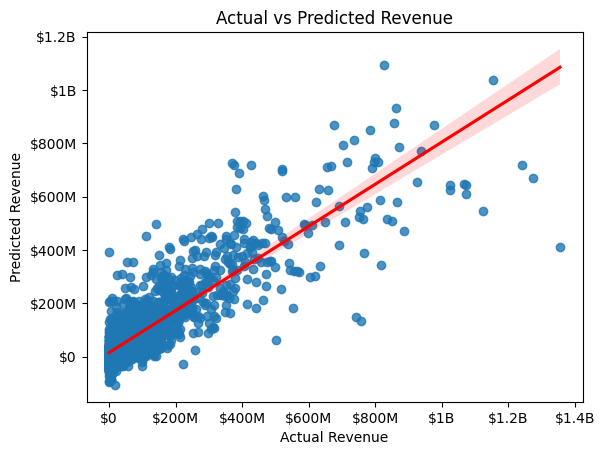

In [30]:
X = clean_df.drop(columns=['revenue'])
y = clean_df['revenue']

x_train, x_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.3, 
    random_state=42
)


model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)


mse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Percentage Error: {mape}")
print(f"R^2 Score: {r2}")


ax = sns.regplot(x=y_test, y=y_pred, line_kws={"color": "red"})
ax.set_xlabel("Actual Revenue")
ax.set_ylabel("Predicted Revenue")
ax.set_title("Actual vs Predicted Revenue")
plt.gca().xaxis.set_major_formatter(formatter)
plt.gca().yaxis.set_major_formatter(formatter)
plt.show()


### Part 3: Feature Engineering

In [ ]:
engineered_df = movies_df.copy()

# Replace Revenue and Budget with 1k or less with pd.Na 
engineered_df['revenue'] = engineered_df['revenue'].apply(lambda x: x if x > 1e3 else pd.NA)
engineered_df['budget'] = engineered_df['budget'].apply(lambda x: x if x > 1e3 else pd.NA)

# Drop rows with NA values in the revenue column
engineered_df.dropna(subset=['revenue'], inplace=True)
engineered_df.reset_index(drop=True, inplace=True)

# extract release month and release year from release_date column
engineered_df['release_month'] = engineered_df['release_date'].dt.month.apply(convert_to_month_name).astype('category')
engineered_df['release_year'] = engineered_df['release_date'].dt.year.astype('Int64')

# Calculate the mean and convert to integer
mean_revenue = int(engineered_df['revenue'].mean())
mean_budget = int(engineered_df['budget'].mean())

# Fill missing values with the integer mean
engineered_df['revenue'] = engineered_df['revenue'].fillna(mean_revenue)
engineered_df['budget'] = engineered_df['budget'].fillna(mean_budget)


# Clean the runtime
engineered_df['runtime'] = engineered_df['runtime'].where(engineered_df['runtime'] > 0, pd.NA)

# bins for media format based on runtime
bins = [0, 40, 301, np.inf] 
labels = ['Short Film', 'Feature Film', 'TV Show/Collection']

# Create the new feature using pd.cut
engineered_df['media_format'] = pd.cut(
    engineered_df['runtime'], 
    bins=bins, 
    labels=labels, 
    right=False 
)



# Extract number of genres, production companies, production countries, and spoken languages as new features
engineered_df['num_genres'] = engineered_df['genres'].apply(lambda x: len(x.split(',')) if pd.notna(x) else 0)
engineered_df['num_production_companies'] = engineered_df['production_companies'].apply(lambda x: len(x.split(',')) if pd.notna(x) else 0)
engineered_df['num_production_countries'] = engineered_df['production_countries'].apply(lambda x: len(x.split(',')) if pd.notna(x) else 0)
engineered_df['num_spoken_languages'] = engineered_df['spoken_languages'].apply(lambda x: len(x.split(',')) if pd.notna(x) else 0)  

# One-hot encode release_month
engineered_df = pd.get_dummies(engineered_df, columns=['release_month'], drop_first=True)   

# Drop str, object, and datetime columns that won't be used for modeling
engineered_df.drop(columns=engineered_df.select_dtypes(include=['object','str', 'datetime']).columns, inplace=True)




In [32]:
engineered_df.info()
engineered_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 18315 entries, 0 to 18314
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   vote_average              18315 non-null  float64
 1   vote_count                15734 non-null  Int64  
 2   revenue                   18315 non-null  int64  
 3   runtime                   17165 non-null  Int64  
 4   adult                     18315 non-null  bool   
 5   budget                    18315 non-null  int64  
 6   popularity                18315 non-null  float64
 7   release_year              17083 non-null  Int64  
 8   num_genres                18315 non-null  int64  
 9   num_production_companies  18315 non-null  int64  
 10  num_production_countries  18315 non-null  int64  
 11  num_spoken_languages      18315 non-null  int64  
 12  release_month_August      18315 non-null  bool   
 13  release_month_December    18315 non-null  bool   
 14  release_month_Feb

,vote_average,vote_count,revenue,runtime,budget,popularity,release_year,num_genres,num_production_companies,num_production_countries,num_spoken_languages
count,18315.000000,15734.0,1.831500e+04,17165.0,1.831500e+04,18315.000000,17083.0,18315.000000,18315.000000,18315.000000,18315.000000
mean,5.496407,1024.982204,4.430725e+07,104.00769,2.189803e+07,13.186153,2003.519991,2.258804,2.675566,1.323232,1.353808
std,2.500305,2414.157968,1.263614e+08,43.643654,3.075734e+07,46.932929,18.168879,1.099735,2.274662,0.781477,0.815827
min,0.000000,1.0,1.012000e+03,1.0,1.015000e+03,0.000000,1800.0,1.000000,1.000000,1.000000,1.000000
25%,5.225500,26.0,2.431610e+05,90.0,3.800000e+06,1.647000,1996.0,1.000000,1.000000,1.000000,1.000000
50%,6.200000,179.0,3.563603e+06,101.0,2.189803e+07,8.085000,2009.0,2.000000,2.000000,1.000000,1.000000
75%,6.943000,833.0,2.579616e+07,117.0,2.189803e+07,15.445500,2016.0,3.000000,3.000000,1.000000,1.000000
max,10.000000,34495.0,1.488733e+09,999.0,6.456547e+08,2994.357000,2030.0,17.000000,30.000000,20.000000,16.000000


##### 3.# Improved Model

### Part 4: Additional Data

##### 4.# Model Improved with Additional Data


### Part 5: More Complex Models

### Part 6: Model Comparisons

### Part 7: Minimum Model

### Part 8: Final Analysis